In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression,Lasso ,Ridge,ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df=pd.read_csv("House Price.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape

(1460, 81)

In [4]:
df.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [5]:
df=df.drop(columns=['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu'])

In [6]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 75, dtype: object

In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

C:\Users\MasterLaptops\AppData\Local\Temp\ipykernel_21368\3515154846.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


In [8]:
for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

for cil in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

In [9]:
df.isnull().sum().sort_values(ascending=False)

GarageFinish     81
GarageCond       81
GarageQual       81
GarageType       81
BsmtFinType2     38
                 ..
MoSold            0
YrSold            0
SaleType          0
SaleCondition     0
SalePrice         0
Length: 75, dtype: int64

In [10]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'Enclo

In [11]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [12]:
# garage_finish_map = {'Unf': 1, 'RFn': 2, 'Fin': 3}

# df['GarageFinish'] = df['GarageFinish'].map(garage_finish_map)

df = pd.get_dummies(df, columns=cat_cols, dtype=int)


In [13]:
df.dtypes

Id                         int64
MSSubClass                 int64
LotFrontage              float64
LotArea                    int64
OverallQual                int64
                          ...   
SaleCondition_AdjLand      int64
SaleCondition_Alloca       int64
SaleCondition_Family       int64
SaleCondition_Normal       int64
SaleCondition_Partial      int64
Length: 268, dtype: object

In [14]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:

models = {
    'Dummy Regressor': DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(alpha=1.0, max_iter=10000),
    'Ridge': Ridge(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():
   
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print(results_df)


best_model_name=results_df.loc[0,'Model']
best_r2_score=results_df.loc[0,'R2 Score']
best_rmse=results_df.loc[0,'RMSE']

best_model_object=models[best_model_name]

print(f" BEST MODEL SELECTED: {best_model_name.upper()}")
print(f" R2 Score: {best_r2_score:.4f}")
print(f" RMSE: {best_rmse:.4f}")


c:\Users\MasterLaptops\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.783e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


               Model           MAE           MSE          RMSE  R2 Score
0            XGBoost  16948.861328  7.420577e+08  27240.736554  0.903256
1  Gradient Boosting  17376.121576  7.795095e+08  27919.697740  0.898373
2              Lasso  18045.583887  7.995979e+08  28277.162935  0.895754
3      Random Forest  17626.781233  8.179685e+08  28600.149288  0.893359
4              Ridge  18738.783391  8.467070e+08  29098.229493  0.889613
5  Linear Regression  18501.579763  8.842306e+08  29736.015498  0.884721
6         ElasticNet  20315.404437  1.224383e+09  34991.183560  0.840374
7      Decision Tree  26342.414384  1.618943e+09  40236.089133  0.788934
8    Dummy Regressor  62575.926452  7.677095e+09  87619.034506 -0.000882
 BEST MODEL SELECTED: XGBOOST
 R2 Score: 0.9033
 RMSE: 27240.7366


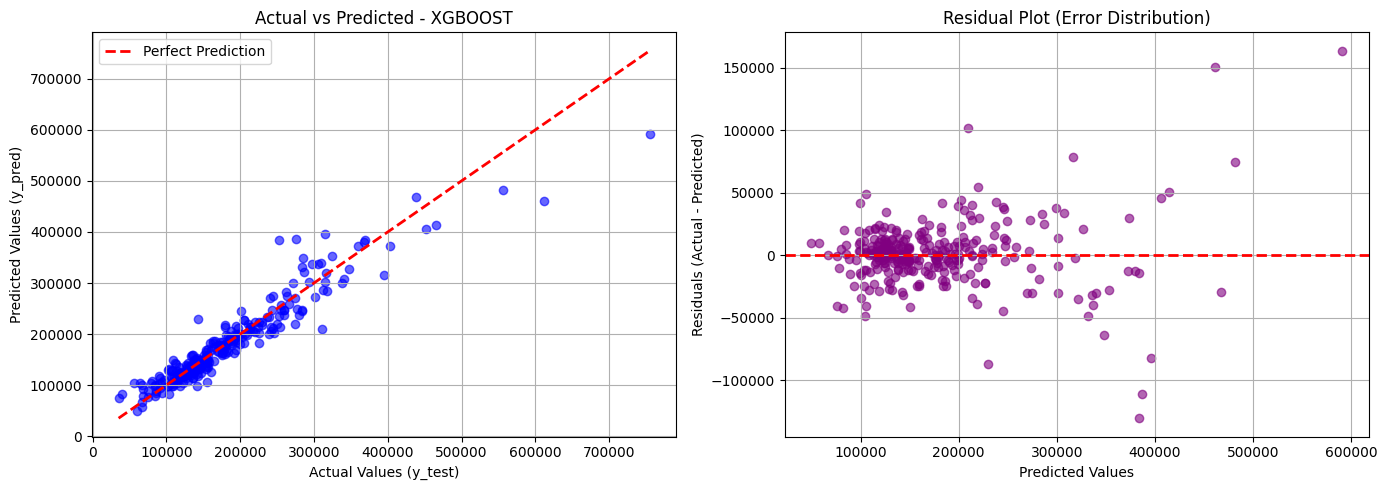

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get predictions from the best model
y_pred = best_model_object.predict(X_test)
residuals = y_test - y_pred

# Set up graph layout
plt.figure(figsize=(14, 5))

# Graph 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Prediction")
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title(f"Actual vs Predicted - {best_model_name.upper()}")
plt.legend()
plt.grid(True)

# Graph 2: Residuals Plot
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Error Distribution)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
# Create a manual verification DataFrame
verification_df = pd.DataFrame({
    'Actual Value': y_test.values if hasattr(y_test, 'values') else y_test,
    'Predicted Value': np.round(y_pred, 2),
    'Absolute Error': np.round(np.abs(y_test - y_pred), 2)
})

print("--- MANUAL VERIFICATION (FIRST 10 SAMPLES) ---")
print(verification_df.head(10).to_string(index=True))

--- MANUAL VERIFICATION (FIRST 10 SAMPLES) ---
      Actual Value  Predicted Value  Absolute Error
892         154500    148701.218750         5798.78
1105        325000    353027.531250        28027.53
413         115000    111073.343750         3926.66
522         159000    183544.296875        24544.30
1036        315500    301443.750000        14056.25
614          75500     75924.140625          424.13
218         311500    209880.437500       101619.56
1160        146000    149744.968750         3744.97
649          84500     79663.359375         4836.63
887         135500    123497.453125        12002.55


In [18]:
import joblib

# 1. Model save karein
joblib.dump(best_model_object, 'best_model.pkl')

# 2. Model ke exact training columns save karein
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')
print("Model and columns saved successfully!")

Model and columns saved successfully!
